# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [9]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,  cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import urllib.request
import seaborn as sns
import matplotlib.pyplot as plt
import toolbox_ML_v2 as tl
import re
import bootcampviztools as bt

from transformer import (
    transformer_screenresolution,
    transformer_cpu,
    transformer_memory,
    transformer_gpu,
    transformer_weight,
    transformer_ram,)

## 2. Datos

In [10]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col = 'laptop_ID')

### 2.1 Exploración de los datos

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [12]:
# df.head()

In [13]:
# df.tail()

In [14]:
# df.describe()

| Columna            | Qué significa                                                                | Por qué afecta el precio                                                     | Transformaciones típicas (buenas prácticas)                                                                                       |
| ------------------ | ---------------------------------------------------------------------------- | ---------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| `Company`          | Marca (Dell, HP, Apple, Lenovo, etc.)                                        | La marca captura posicionamiento (premium vs budget), garantía, distribución | Categórica: One-Hot, Target Encoding (con CV), o embeddings en modelos DL                                                         |
| `Product`          | Nombre/modelo comercial (ej. “XPS 13”, “MacBook Pro”)                        | Puede codificar gama exacta, generación, submodelo; riesgo de “memorizar”    | Suele ser de alta cardinalidad: limpiar texto + extraer tokens (serie), o directamente excluir si es ID-like y puede sobreajustar |
| `TypeName`         | Tipo/form factor (Ultrabook, Gaming, Notebook, Workstation, 2-in-1)          | Segmento de mercado; gaming/workstation suben precio                         | One-Hot; también agrupar categorías raras                                                                                         |
| `Inches`           | Tamaño de pantalla en pulgadas                                               | Tamaño correlaciona con costo; pero no siempre (ultrabooks)                  | Numérica continua; revisar outliers; puede interactuar con resolución/peso                                                        |
| `ScreenResolution` | Resolución y tipo de panel (ej. “1920x1080”, “IPS”, “Touchscreen”, “4K”)     | Gran driver de precio: 4K, IPS, táctil, etc.                                 | Parsear: `width`, `height`, `ppi`, flags `is_touch`, `is_ips`, `is_4k`, `is_retina`                                               |
| `Cpu`              | Procesador (marca + línea + modelo + frecuencia; ej. “Intel Core i7 2.7GHz”) | De los drivers más fuertes: i3/i5/i7, Ryzen; generación/modelo               | Parsear: `cpu_brand`, `cpu_family`, `cpu_model`, `cpu_ghz`, y si se puede, `cpu_tier` (i3<i5<i7<i9)                               |
| `Ram`              | Memoria RAM (ej. “8GB”)                                                      | RAM sube precio, especialmente en gamas altas                                | Extraer número: `ram_gb` (int). Considerar log/escala.                                                                            |
| `Memory`           | Almacenamiento (ej. “256GB SSD”, “1TB HDD”, “128GB SSD + 1TB HDD”)           | SSD vs HDD cambia precio; capacidad total también                            | Parsear: `ssd_gb`, `hdd_gb`, `flash_gb`, `hybrid_gb`, `total_storage_gb`, `has_ssd`                                               |
| `Gpu`              | Placa gráfica (ej. “Nvidia GeForce GTX 1050”, “Intel HD Graphics”)           | GPU dedicada y gama (GTX/RTX/Quadro) impactan fuerte                         | Parsear: `gpu_brand` (Intel/Nvidia/AMD), `is_dedicated`, `gpu_series` (GTX/RTX), quizá “tier”                                     |
| `OpSys`            | Sistema operativo (Windows, macOS, Linux, No OS)                             | macOS suele ser premium (pero es proxy de Apple); “No OS” abarata            | One-Hot; agrupar variantes (“Windows 10/11” → “Windows”)                                                                          |
| `Weight`           | Peso (ej. “1.37kg”)                                                          | Ultrabooks livianos tienden a ser más caros; gaming pesa más                 | Extraer número: `weight_kg`. Revisar outliers                                                                                     |


### 2.3 Definir X e y

In [15]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

In [16]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [18]:
X_train.shape

(729, 11)

In [19]:
X_test.shape

(183, 11)

In [20]:
y_train.shape

(729,)

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [21]:
target = 'Price_in_euros'

In [22]:
# X_train.tail()

In [23]:
# for col in X_train.columns:
#     print(f'{col}: {X_train[col].nunique()}=')
#     print(X_train[col].value_counts())
#     print('\n')

#### Tratamiento de columnas Company, TypeName y OpSys (One-Hot Encoding)

In [24]:
one_hot = ['Company','TypeName','OpSys','Inches']

In [25]:
for col in one_hot:
    X_train = pd.get_dummies(X_train, columns=[col], dtype= int)
    X_test = pd.get_dummies(X_test, columns=[col], dtype= int)

In [26]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_test = X_test[X_train.columns]

In [27]:
print(X_train.shape)
print(X_test.shape)

(729, 54)
(183, 54)


#### Tratamiento columna ScreenResolution

In [30]:
screen_tr = transformer_screenresolution(X_train)
screen_ts = transformer_screenresolution(X_test)

In [20]:
sr_unicos  = X_train['ScreenResolution'].unique()

In [21]:
# X_train
Res_X = []
Res_Y = []
Touchscreen = []

for i in range(len(X_train)):
    s = str(X_train.iloc[i]['ScreenResolution']).strip()

    # Touchscreen
    touch = 1 if 'Touchscreen' in s else 0

    # Resolución XxY
    m = re.search(r'(\d{3,4})x(\d{3,4})', s)
    if m:
        x = int(m.group(1))
        y = int(m.group(2))
    else:
        x = 0
        y = 0

    Res_X.append(x)
    Res_Y.append(y)
    Touchscreen.append(touch)

X_train['Res_X'] = Res_X
X_train['Res_Y'] = Res_Y
X_train['Touchscreen'] = Touchscreen


In [22]:
# X_train[['ScreenResolution','Res_X','Res_Y','Touchscreen']].sample(20, random_state=0)

In [23]:
# X_test
Res_X = []
Res_Y = []
Touchscreen = []

for i in range(len(X_test)):
    s = str(X_test.iloc[i]['ScreenResolution']).strip()

    # Touchscreen
    touch = 1 if 'Touchscreen' in s else 0

    # Resolución XxY
    m = re.search(r'(\d{3,4})x(\d{3,4})', s)
    if m:
        x = int(m.group(1))
        y = int(m.group(2))
    else:
        x = 0
        y = 0

    Res_X.append(x)
    Res_Y.append(y)
    Touchscreen.append(touch)

X_test['Res_X'] = Res_X
X_test['Res_Y'] = Res_Y
X_test['Touchscreen'] = Touchscreen

In [24]:
# X_test[['ScreenResolution','Res_X','Res_Y','Touchscreen']].sample(20, random_state=0)

In [25]:
print(X_train.shape)
print(X_test.shape)

(729, 57)
(183, 57)


#### Tratamiento columna Gpu

In [26]:
gpu_unicos  = X_train['Gpu'].unique()

In [33]:
gpu_tr = transformer_gpu(X_train)
gpu_ts = transformer_gpu(X_test)

In [27]:
# X_train
GPU_Intel = []
GPU_Nvidia = []
GPU_AMD = []
GPU_Other = []

GPU_Dedicada = []

GPU_GTX = []
GPU_RTX = []
GPU_MX = []
GPU_Quadro = []
GPU_RX = []
GPU_FirePro = []

GPU_GTX_Num = []
GPU_MX_Num = []
GPU_Quadro_Num = []
GPU_RX_Num = []

GPU_Iris = []
GPU_HD = []
GPU_UHD = []

# NUEVAS (para capturar Intel HD/UHD/Iris y AMD Radeon "sin RX")
GPU_Intel_Num = []
GPU_Radeon_Num = []

# --- LOOP (X_train) ---
for i in range(len(X_train)):
    s = str(X_train.iloc[i]['Gpu']).strip( )
    s_low = s.lower()

    # Marca 
    gpu_intel = 1 if 'intel' in s_low else 0
    gpu_nvidia = 1 if 'nvidia' in s_low else 0
    gpu_amd = 1 if 'amd' in s_low else 0
    gpu_other = 1 if (gpu_intel == 0 and gpu_nvidia == 0 and gpu_amd == 0) else 0

    # Familias / segmentos
    gpu_quadro = 1 if 'quadro' in s_low else 0
    gpu_gtx = 1 if 'gtx' in s_low else 0
    gpu_rtx = 1 if 'rtx' in s_low else 0  # por si aparece
    gpu_mx = 1 if re.search(r'\bmx\s*\d', s_low) else 0  # mx130/mx150...
    gpu_rx = 1 if ('radeon rx' in s_low) or re.search(r'\brx\s*\d', s_low) else 0
    gpu_firepro = 1 if 'firepro' in s_low else 0

    # Intel integradas (opcionales, pero útiles)
    gpu_iris = 1 if 'iris' in s_low else 0
    gpu_hd = 1 if 'hd graphics' in s_low else 0
    gpu_uhd = 1 if 'uhd graphics' in s_low else 0

    # Dedicada vs integrada (regla práctica)
    gpu_dedicada = 1 if (gpu_nvidia == 1 or gpu_quadro == 1 or gpu_rx == 1 or gpu_firepro == 1 or ('radeon' in s_low and gpu_amd == 1)) else 0

    # Números por familia (0 si no aplica)
    gtx_num = 0
    mx_num = 0
    quadro_num = 0
    rx_num = 0

    if gpu_gtx == 1:
        m = re.search(r'gtx\s*([0-9]{3,4})', s_low)
        gtx_num = int(m.group(1)) if m else 1

    if gpu_mx == 1:
        m = re.search(r'mx\s*([0-9]{2,4})', s_low)
        mx_num = int(m.group(1)) if m else 1

    if gpu_quadro == 1:
        # ejemplos: "Nvidia Quadro M1200", "Nvidia Quadro M2000M"
        m = re.search(r'quadro\s*[a-z]*\s*([0-9]{3,4})', s_low)
        quadro_num = int(m.group(1)) if m else 1

    if gpu_rx == 1:
        m = re.search(r'rx\s*([0-9]{3,4})', s_low)
        rx_num = int(m.group(1)) if m else 1

    # NUEVO: Intel HD/UHD/Iris + número (ej: 405, 520, 620...)
    intel_num = 0
    if gpu_intel == 1:
        m = re.search(r'(hd graphics|uhd graphics|iris( plus)?)\s*([0-9]{3,4})', s_low)
        if m:
            intel_num = int(m.group(3))
        else:
            # fallback: cualquier 3-4 dígitos si aparece
            m = re.search(r'(\d{3,4})', s_low)
            intel_num = int(m.group(1)) if m else 0

    # NUEVO: AMD Radeon "sin RX" + número (ej: Radeon 530)
    radeon_num = 0
    if gpu_amd == 1 and 'radeon' in s_low and gpu_rx == 0:
        m = re.search(r'radeon\s*([0-9]{3,4})', s_low)
        radeon_num = int(m.group(1)) if m else 0

    # Append (1 por fila en cada lista)
    GPU_Intel.append(gpu_intel)
    GPU_Nvidia.append(gpu_nvidia)
    GPU_AMD.append(gpu_amd)
    GPU_Other.append(gpu_other)

    GPU_Dedicada.append(gpu_dedicada)

    GPU_GTX.append(gpu_gtx)
    GPU_RTX.append(gpu_rtx)
    GPU_MX.append(gpu_mx)
    GPU_Quadro.append(gpu_quadro)
    GPU_RX.append(gpu_rx)
    GPU_FirePro.append(gpu_firepro)

    GPU_GTX_Num.append(gtx_num)
    GPU_MX_Num.append(mx_num)
    GPU_Quadro_Num.append(quadro_num)
    GPU_RX_Num.append(rx_num)

    GPU_Iris.append(gpu_iris)
    GPU_HD.append(gpu_hd)
    GPU_UHD.append(gpu_uhd)

    GPU_Intel_Num.append(intel_num)
    GPU_Radeon_Num.append(radeon_num)


X_train['GPU_Intel'] = GPU_Intel
X_train['GPU_Nvidia'] = GPU_Nvidia
X_train['GPU_AMD'] = GPU_AMD
X_train['GPU_Other'] = GPU_Other

X_train['GPU_Dedicada'] = GPU_Dedicada

X_train['GPU_GTX'] = GPU_GTX
X_train['GPU_RTX'] = GPU_RTX
X_train['GPU_MX'] = GPU_MX
X_train['GPU_Quadro'] = GPU_Quadro
X_train['GPU_RX'] = GPU_RX
X_train['GPU_FirePro'] = GPU_FirePro

X_train['GPU_GTX_Num'] = GPU_GTX_Num
X_train['GPU_MX_Num'] = GPU_MX_Num
X_train['GPU_Quadro_Num'] = GPU_Quadro_Num
X_train['GPU_RX_Num'] = GPU_RX_Num

X_train['GPU_Iris'] = GPU_Iris
X_train['GPU_HD'] = GPU_HD
X_train['GPU_UHD'] = GPU_UHD

X_train['GPU_Intel_Num'] = GPU_Intel_Num
X_train['GPU_Radeon_Num'] = GPU_Radeon_Num


In [28]:

# X_train[['Gpu',
#          'GPU_Dedicada',
#          'GPU_Intel','GPU_Intel_Num',
#          'GPU_Nvidia',
#          'GPU_GTX','GPU_GTX_Num',
#          'GPU_MX','GPU_MX_Num',
#          'GPU_Quadro','GPU_Quadro_Num',
#          'GPU_AMD','GPU_RX','GPU_RX_Num','GPU_Radeon_Num',
#          'GPU_FirePro'
#         ]].sample(20, random_state=0)


In [29]:
# X_test
GPU_Intel = []
GPU_Nvidia = []
GPU_AMD = []
GPU_Other = []

GPU_Dedicada = []

GPU_GTX = []
GPU_RTX = []
GPU_MX = []
GPU_Quadro = []
GPU_RX = []
GPU_FirePro = []

GPU_GTX_Num = []
GPU_MX_Num = []
GPU_Quadro_Num = []
GPU_RX_Num = []

GPU_Iris = []
GPU_HD = []
GPU_UHD = []

# NUEVAS (para capturar Intel HD/UHD/Iris y AMD Radeon "sin RX")
GPU_Intel_Num = []
GPU_Radeon_Num = []

# --- LOOP (X_test) ---
for i in range(len(X_test)):
    s = str(X_test.iloc[i]['Gpu']).strip()
    s_low = s.lower()

    # Marca
    gpu_intel = 1 if 'intel' in s_low else 0
    gpu_nvidia = 1 if 'nvidia' in s_low else 0
    gpu_amd = 1 if 'amd' in s_low else 0
    gpu_other = 1 if (gpu_intel == 0 and gpu_nvidia == 0 and gpu_amd == 0) else 0

    # Familias / segmentos
    gpu_quadro = 1 if 'quadro' in s_low else 0
    gpu_gtx = 1 if 'gtx' in s_low else 0
    gpu_rtx = 1 if 'rtx' in s_low else 0  # por si aparece
    gpu_mx = 1 if re.search(r'\bmx\s*\d', s_low) else 0  # mx130/mx150...
    gpu_rx = 1 if ('radeon rx' in s_low) or re.search(r'\brx\s*\d', s_low) else 0
    gpu_firepro = 1 if 'firepro' in s_low else 0

    # Intel integradas (opcionales, pero útiles)
    gpu_iris = 1 if 'iris' in s_low else 0
    gpu_hd = 1 if 'hd graphics' in s_low else 0
    gpu_uhd = 1 if 'uhd graphics' in s_low else 0

    # Dedicada vs integrada (regla práctica)
    gpu_dedicada = 1 if (gpu_nvidia == 1 or gpu_quadro == 1 or gpu_rx == 1 or gpu_firepro == 1 or ('radeon' in s_low and gpu_amd == 1)) else 0

    # Números por familia (0 si no aplica)
    gtx_num = 0
    mx_num = 0
    quadro_num = 0
    rx_num = 0

    if gpu_gtx == 1:
        m = re.search(r'gtx\s*([0-9]{3,4})', s_low)
        gtx_num = int(m.group(1)) if m else 1

    if gpu_mx == 1:
        m = re.search(r'mx\s*([0-9]{2,4})', s_low)
        mx_num = int(m.group(1)) if m else 1

    if gpu_quadro == 1:
        # ejemplos: "Nvidia Quadro M1200", "Nvidia Quadro M2000M"
        m = re.search(r'quadro\s*[a-z]*\s*([0-9]{3,4})', s_low)
        quadro_num = int(m.group(1)) if m else 1

    if gpu_rx == 1:
        m = re.search(r'rx\s*([0-9]{3,4})', s_low)
        rx_num = int(m.group(1)) if m else 1

    # NUEVO: Intel HD/UHD/Iris + número (ej: 405, 520, 620...)
    intel_num = 0
    if gpu_intel == 1:
        m = re.search(r'(hd graphics|uhd graphics|iris( plus)?)\s*([0-9]{3,4})', s_low)
        if m:
            intel_num = int(m.group(3))
        else:
            # fallback: cualquier 3-4 dígitos si aparece
            m = re.search(r'(\d{3,4})', s_low)
            intel_num = int(m.group(1)) if m else 0

    # NUEVO: AMD Radeon "sin RX" + número (ej: Radeon 530)
    radeon_num = 0
    if gpu_amd == 1 and 'radeon' in s_low and gpu_rx == 0:
        m = re.search(r'radeon\s*([0-9]{3,4})', s_low)
        radeon_num = int(m.group(1)) if m else 0

    # Append (1 por fila en cada lista)
    GPU_Intel.append(gpu_intel)
    GPU_Nvidia.append(gpu_nvidia)
    GPU_AMD.append(gpu_amd)
    GPU_Other.append(gpu_other)

    GPU_Dedicada.append(gpu_dedicada)

    GPU_GTX.append(gpu_gtx)
    GPU_RTX.append(gpu_rtx)
    GPU_MX.append(gpu_mx)
    GPU_Quadro.append(gpu_quadro)
    GPU_RX.append(gpu_rx)
    GPU_FirePro.append(gpu_firepro)

    GPU_GTX_Num.append(gtx_num)
    GPU_MX_Num.append(mx_num)
    GPU_Quadro_Num.append(quadro_num)
    GPU_RX_Num.append(rx_num)

    GPU_Iris.append(gpu_iris)
    GPU_HD.append(gpu_hd)
    GPU_UHD.append(gpu_uhd)

    GPU_Intel_Num.append(intel_num)
    GPU_Radeon_Num.append(radeon_num)

# --- ASIGNAR COLUMNAS AL DF ---
X_test['GPU_Intel'] = GPU_Intel
X_test['GPU_Nvidia'] = GPU_Nvidia
X_test['GPU_AMD'] = GPU_AMD
X_test['GPU_Other'] = GPU_Other

X_test['GPU_Dedicada'] = GPU_Dedicada

X_test['GPU_GTX'] = GPU_GTX
X_test['GPU_RTX'] = GPU_RTX
X_test['GPU_MX'] = GPU_MX
X_test['GPU_Quadro'] = GPU_Quadro
X_test['GPU_RX'] = GPU_RX
X_test['GPU_FirePro'] = GPU_FirePro

X_test['GPU_GTX_Num'] = GPU_GTX_Num
X_test['GPU_MX_Num'] = GPU_MX_Num
X_test['GPU_Quadro_Num'] = GPU_Quadro_Num
X_test['GPU_RX_Num'] = GPU_RX_Num

X_test['GPU_Iris'] = GPU_Iris
X_test['GPU_HD'] = GPU_HD
X_test['GPU_UHD'] = GPU_UHD

X_test['GPU_Intel_Num'] = GPU_Intel_Num
X_test['GPU_Radeon_Num'] = GPU_Radeon_Num


In [30]:
# X_test[['Gpu',
#          'GPU_Dedicada',
#          'GPU_Intel','GPU_Intel_Num',
#          'GPU_Nvidia',
#          'GPU_GTX','GPU_GTX_Num',
#          'GPU_MX','GPU_MX_Num',
#          'GPU_Quadro','GPU_Quadro_Num',
#          'GPU_AMD','GPU_RX','GPU_RX_Num','GPU_Radeon_Num',
#          'GPU_FirePro'
#         ]].sample(20, random_state=0)


In [31]:
print(X_train.shape)
print(X_test.shape)

(729, 77)
(183, 77)


#### Tratamiento columna Cpu

In [32]:
cpu_unicos  = X_train['Cpu'].unique()

In [34]:
cpu_tr = transformer_cpu(X_train)
cpu_ts = transformer_cpu(X_test)

In [33]:
#Train
CPU_Intel = []
CPU_AMD = []
CPU_Other = []

CPU_Core_Ord = []
CPU_CoreM_Ord = []
CPU_Ryzen_Ord = []
CPU_ASeries_Ord = []

CPU_Celeron = []
CPU_Pentium = []
CPU_Atom = []
CPU_ESeries = []
CPU_OtherFamily = []

CPU_GHz = []

for i in range(len(X_train)):
    s = str(X_train.iloc[i]['Cpu']).strip()
    s_low = s.lower()

    # ---- marca ----
    intel = 1 if 'intel' in s_low else 0
    amd = 1 if 'amd' in s_low else 0
    other_brand = 1 if (intel == 0 and amd == 0) else 0

    # ---- ordinal por familia (lo que querés) ----
    core_ord = 0
    corem_ord = 0
    ryzen_ord = 0
    aseries_ord = 0

    # ---- flags de otras familias ----
    celeron = 0
    pentium = 0
    atom = 0
    eseries = 0
    other_family = 0

    # 1) Intel Core i3/i5/i7/i9 -> guardar el numerito
    m = re.search(r'core\s+i\s*([3579])', s_low)
    if m:
        core_ord = int(m.group(1))
    else:
        # 2) Intel Core M (M3/M5/M7) -> guardar 3/5/7 si aparece
        m = re.search(r'core\s+m\s*(m)?\s*([357])\b', s_low)
        if m:
            corem_ord = int(m.group(2))
        else:
            # 3) Ryzen 3/5/7/9
            m = re.search(r'ryzen\s*([3579])', s_low)
            if m:
                ryzen_ord = int(m.group(1))
            else:
                # 4) AMD A-Series A6/A8/A9/A10/A12
                m = re.search(r'\ba\s*(6|8|9|10|12)\b', s_low)
                if m:
                    aseries_ord = int(m.group(1))
                else:
                    # 5) E-Series / Celeron / Pentium / Atom (flags)
                    if 'e-series' in s_low or re.search(r'\be\s*-\s*series\b', s_low):
                        eseries = 1
                    elif 'celeron' in s_low:
                        celeron = 1
                    elif 'pentium' in s_low:
                        pentium = 1
                    elif 'atom' in s_low:
                        atom = 1
                    else:
                        other_family = 1

    # ---- GHz ----
    m = re.search(r'(\d+(\.\d+)?)\s*ghz', s_low)
    ghz = float(m.group(1)) if m else np.nan

    # ---- append ----
    CPU_Intel.append(intel)
    CPU_AMD.append(amd)
    CPU_Other.append(other_brand)

    CPU_Core_Ord.append(core_ord)
    CPU_CoreM_Ord.append(corem_ord)
    CPU_Ryzen_Ord.append(ryzen_ord)
    CPU_ASeries_Ord.append(aseries_ord)

    CPU_Celeron.append(celeron)
    CPU_Pentium.append(pentium)
    CPU_Atom.append(atom)
    CPU_ESeries.append(eseries)
    CPU_OtherFamily.append(other_family)

    CPU_GHz.append(ghz)

# asignar columnas
X_train['CPU_Intel'] = CPU_Intel
X_train['CPU_AMD'] = CPU_AMD
X_train['CPU_Other'] = CPU_Other

X_train['CPU_Core_Ord'] = CPU_Core_Ord
X_train['CPU_CoreM_Ord'] = CPU_CoreM_Ord
X_train['CPU_Ryzen_Ord'] = CPU_Ryzen_Ord
X_train['CPU_ASeries_Ord'] = CPU_ASeries_Ord

X_train['CPU_Celeron'] = CPU_Celeron
X_train['CPU_Pentium'] = CPU_Pentium
X_train['CPU_Atom'] = CPU_Atom
X_train['CPU_ESeries'] = CPU_ESeries
X_train['CPU_OtherFamily'] = CPU_OtherFamily

X_train['CPU_GHz'] = CPU_GHz


In [34]:
# X_train[['Cpu','CPU_Intel','CPU_AMD','CPU_Other','CPU_Core_Ord','CPU_CoreM_Ord','CPU_Ryzen_Ord','CPU_ASeries_Ord','CPU_GHz']]

In [35]:
#Test
CPU_Intel = []
CPU_AMD = []
CPU_Other = []

CPU_Core_Ord = []
CPU_CoreM_Ord = []
CPU_Ryzen_Ord = []
CPU_ASeries_Ord = []

CPU_Celeron = []
CPU_Pentium = []
CPU_Atom = []
CPU_ESeries = []
CPU_OtherFamily = []

CPU_GHz = []

for i in range(len(X_test)):
    s = str(X_test.iloc[i]['Cpu']).strip()
    s_low = s.lower()

    # marca
    intel = 1 if 'intel' in s_low else 0
    amd = 1 if 'amd' in s_low else 0
    other_brand = 1 if (intel == 0 and amd == 0) else 0

    # ordinal por familia
    core_ord = 0
    corem_ord = 0
    ryzen_ord = 0
    aseries_ord = 0

    # flags otras familias
    celeron = 0
    pentium = 0
    atom = 0
    eseries = 0
    other_family = 0

    m = re.search(r'core\s+i\s*([3579])', s_low)
    if m:
        core_ord = int(m.group(1))
    else:
        m = re.search(r'core\s+m\s*(m)?\s*([357])\b', s_low)
        if m:
            corem_ord = int(m.group(2))
        else:
            m = re.search(r'ryzen\s*([3579])', s_low)
            if m:
                ryzen_ord = int(m.group(1))
            else:
                m = re.search(r'\ba\s*(6|8|9|10|12)\b', s_low)
                if m:
                    aseries_ord = int(m.group(1))
                else:
                    if 'e-series' in s_low or re.search(r'\be\s*-\s*series\b', s_low):
                        eseries = 1
                    elif 'celeron' in s_low:
                        celeron = 1
                    elif 'pentium' in s_low:
                        pentium = 1
                    elif 'atom' in s_low:
                        atom = 1
                    else:
                        other_family = 1

    # GHz
    m = re.search(r'(\d+(\.\d+)?)\s*ghz', s_low)
    ghz = float(m.group(1)) if m else np.nan

    # append
    CPU_Intel.append(intel)
    CPU_AMD.append(amd)
    CPU_Other.append(other_brand)

    CPU_Core_Ord.append(core_ord)
    CPU_CoreM_Ord.append(corem_ord)
    CPU_Ryzen_Ord.append(ryzen_ord)
    CPU_ASeries_Ord.append(aseries_ord)

    CPU_Celeron.append(celeron)
    CPU_Pentium.append(pentium)
    CPU_Atom.append(atom)
    CPU_ESeries.append(eseries)
    CPU_OtherFamily.append(other_family)

    CPU_GHz.append(ghz)

# asignar columnas
X_test['CPU_Intel'] = CPU_Intel
X_test['CPU_AMD'] = CPU_AMD
X_test['CPU_Other'] = CPU_Other

X_test['CPU_Core_Ord'] = CPU_Core_Ord
X_test['CPU_CoreM_Ord'] = CPU_CoreM_Ord
X_test['CPU_Ryzen_Ord'] = CPU_Ryzen_Ord
X_test['CPU_ASeries_Ord'] = CPU_ASeries_Ord

X_test['CPU_Celeron'] = CPU_Celeron
X_test['CPU_Pentium'] = CPU_Pentium
X_test['CPU_Atom'] = CPU_Atom
X_test['CPU_ESeries'] = CPU_ESeries
X_test['CPU_OtherFamily'] = CPU_OtherFamily

X_test['CPU_GHz'] = CPU_GHz


In [36]:
# X_test[['Cpu','CPU_Intel','CPU_AMD','CPU_Other','CPU_Core_Ord','CPU_CoreM_Ord','CPU_Ryzen_Ord','CPU_ASeries_Ord','CPU_GHz']]

In [37]:
print(X_train.shape)
print(X_test.shape)

(729, 90)
(183, 90)


#### Tratamiento columna Memory

In [38]:
unicos  = X_train['Memory'].unique()

In [35]:
memory_tr = transformer_memory(X_train)
memory_ts = transformer_memory(X_test)

In [39]:
# Train
SSD_GB = []
HDD_GB = []
Flash_Storage_GB = []
Hybrid_GB = []

for i in range(len(X_train)):
    memoria_disco = X_train.iloc[i]['Memory']  # string completo, ej "512GB SSD + 1TB HDD"

    # 1) separar en partes (1 o 2) y limpiar espacios
    partes = [p.strip() for p in memoria_disco.split('+')]  # lista de strings

    # 2) acumuladores por fila
    ssd = 0.0
    hdd = 0.0
    flash = 0.0
    hybrid = 0.0

    # 3) procesar cada parte
    for memoria in partes:
        # extraer número
        match = re.search(r'(\d+(\.\d+)?)', memoria)
        if not match:
            continue  # si algo no tiene número, lo salteo

        num = float(match.group(1))

        # unidad -> GB
        if 'TB' in memoria:
            num = num * 1000  # tu regla

        # detectar tipo y sumar
        if 'SSD' in memoria:
            ssd += num
        elif 'HDD' in memoria:
            hdd += num
        elif 'Flash Storage' in memoria:
            flash += num
        elif 'Hybrid' in memoria:
            hybrid += num

    # 4) append (SIEMPRE 1 por lista por fila)
    SSD_GB.append(ssd)
    HDD_GB.append(hdd)
    Flash_Storage_GB.append(flash)
    Hybrid_GB.append(hybrid)

# 5) asignar al dataframe (ahora sí, mismo largo que X_train)
X_train['SSD_GB'] = SSD_GB
X_train['HDD_GB'] = HDD_GB
X_train['Flash_Storage_GB'] = Flash_Storage_GB
X_train['Hybrid_GB'] = Hybrid_GB


In [40]:
# Test

SSD_GB = []
HDD_GB = []
Flash_Storage_GB = []
Hybrid_GB = []

for i in range(len(X_test)):
    memoria_disco = X_test.iloc[i]['Memory']  # string completo, ej "512GB SSD + 1TB HDD"

    # 1) separar en partes (1 o 2) y limpiar espacios
    partes = [p.strip() for p in memoria_disco.split('+')]  # lista de strings

    # 2) acumuladores por fila
    ssd = 0.0
    hdd = 0.0
    flash = 0.0
    hybrid = 0.0

    # 3) procesar cada parte
    for memoria in partes:
        # extraer número
        match = re.search(r'(\d+(\.\d+)?)', memoria)
        if not match:
            continue  # si algo no tiene número, lo salteo

        num = float(match.group(1))

        # unidad -> GB
        if 'TB' in memoria:
            num = num * 1000  # tu regla

        # detectar tipo y sumar
        if 'SSD' in memoria:
            ssd += num
        elif 'HDD' in memoria:
            hdd += num
        elif 'Flash Storage' in memoria:
            flash += num
        elif 'Hybrid' in memoria:
            hybrid += num

    # 4) append (SIEMPRE 1 por lista por fila)
    SSD_GB.append(ssd)
    HDD_GB.append(hdd)
    Flash_Storage_GB.append(flash)
    Hybrid_GB.append(hybrid)

# 5) asignar al dataframe (ahora sí, mismo largo que X_train)
X_test['SSD_GB'] = SSD_GB
X_test['HDD_GB'] = HDD_GB
X_test['Flash_Storage_GB'] = Flash_Storage_GB
X_test['Hybrid_GB'] = Hybrid_GB


In [41]:
# X_test[['Memory','SSD_GB','HDD_GB','Flash_Storage_GB','Hybrid_GB']]

In [42]:
# X_train[['Memory','SSD_GB','HDD_GB','Flash_Storage_GB','Hybrid_GB']]

In [43]:
print(X_train.shape)
print(X_test.shape)

(729, 94)
(183, 94)


#### Tratamiento columnas Ram y Weight

In [44]:
X_train['Ram_GB'] = X_train['Ram'].str.replace('GB','').astype(int)
X_test['Ram_GB'] = X_test['Ram'].str.replace('GB','').astype(int)

In [45]:
X_train['Weight_kg'] = X_train['Weight'].str.replace('kg','').astype(float)
X_test['Weight_kg'] = X_test['Weight'].str.replace('kg','').astype(float)

In [46]:
# X_train.info()

In [47]:
print(X_train.shape)
print(X_test.shape)

(729, 96)
(183, 96)


### Mini EDA

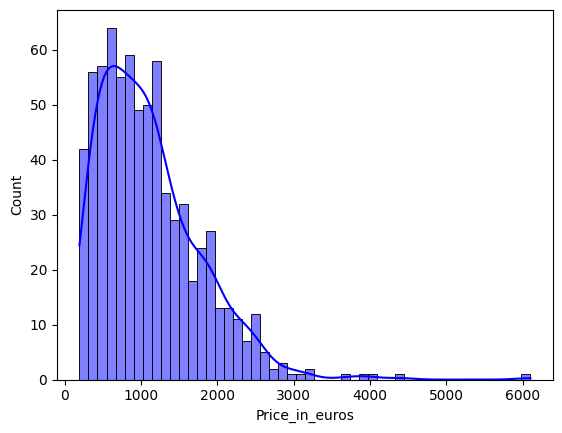

In [48]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

In [49]:
drop = [ 'Product', 'ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'Weight']

In [50]:
X_train_final= X_train.copy()
X_test_final = X_test.copy()

In [51]:
X_train_final = X_train.drop(columns = drop)
X_test_final = X_test.drop(columns = drop)

In [52]:
# tl.describe_df(X_train_final)

In [53]:
# tl.tipifica_variables(X_train_final)

In [54]:
binaria = tl.tipifica_variables(X_train_final)['Categorica_Binaria']
categorica = tl.tipifica_variables(X_train_final)['Categorica_Nominal']
num_discreta = tl.tipifica_variables(X_train_final)['Numerica_Discreta']
num_continua = tl.tipifica_variables(X_train_final)['Numerica_Continua']

In [55]:
print(X_train.shape)
print(y_train.shape)

(729, 96)
(729,)


In [56]:
numericas = num_continua + num_discreta + categorica

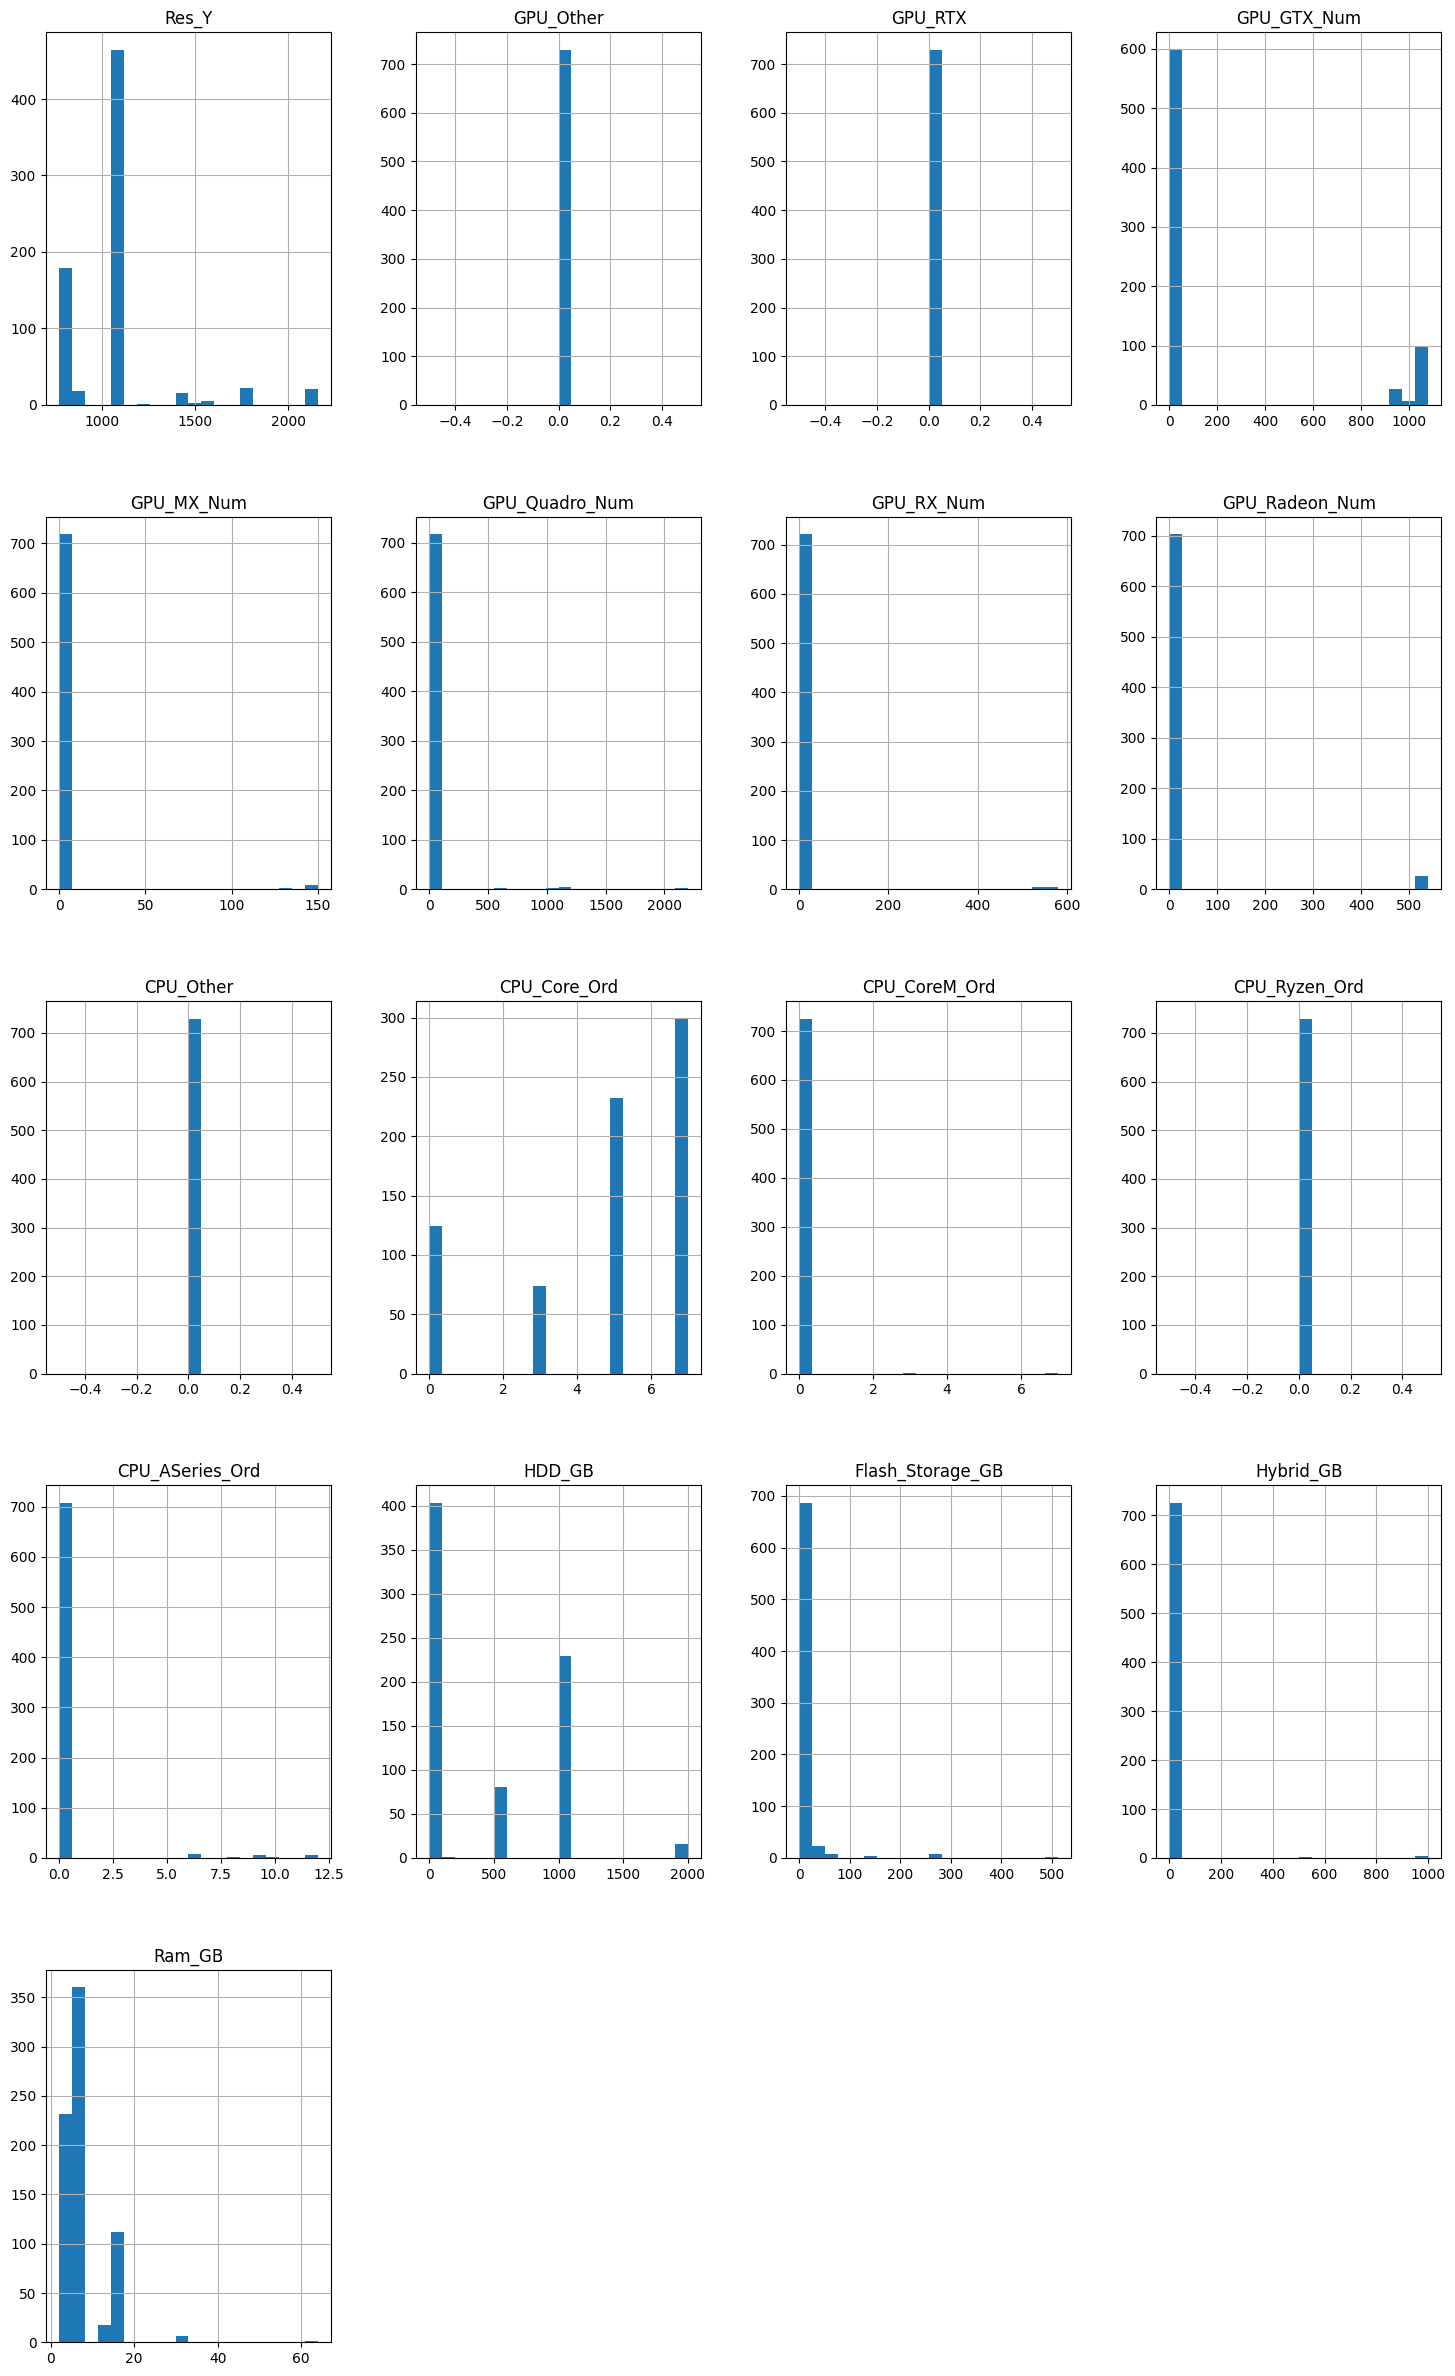

In [57]:
X_train_final[categorica].hist( bins=20, figsize=(18, 30));

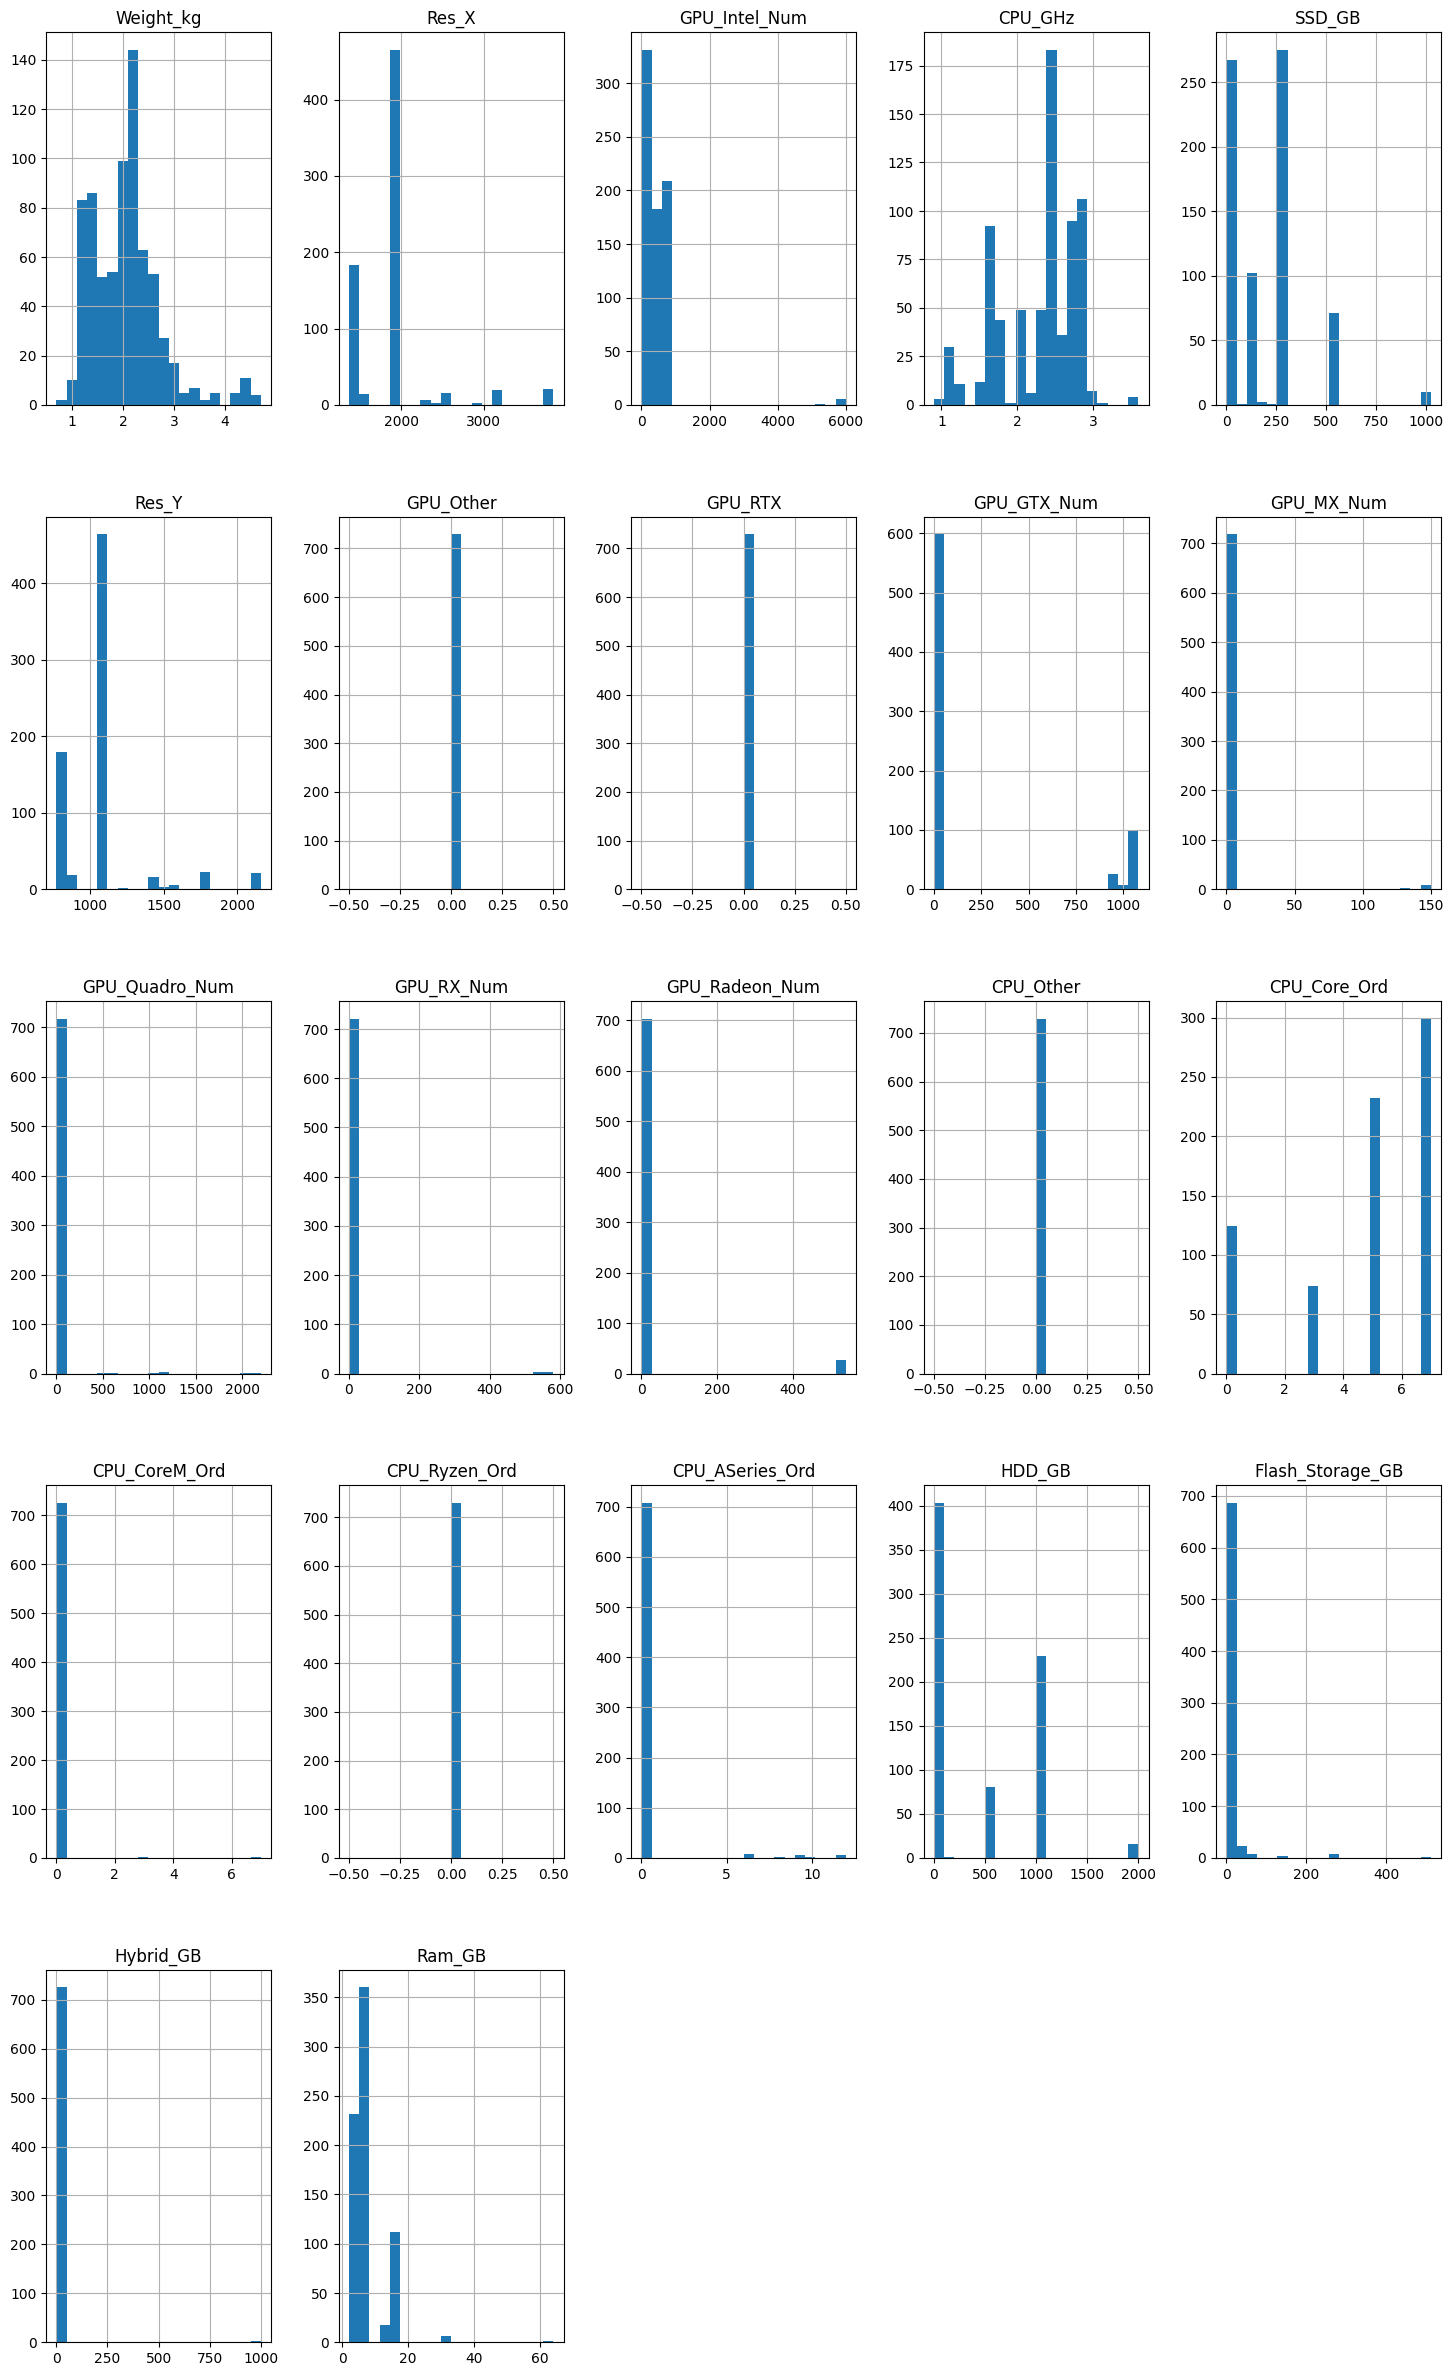

In [58]:
X_train_final[numericas].hist(bins=20, figsize=(18, 30));

In [59]:
dataset = X_train_final.copy()
dataset['Price_in_euros'] = y_train
dataset_test = X_test_final.copy()
dataset_test['Price_in_euros'] = y_test

In [ ]:
 bt.plot_categorical_relationship_fin(dataset, dataset['Price_in_euros'], 'Inches', relative_freq= True, show_values= True)

##### Si saco los outlie

In [60]:
out_target = dataset['Price_in_euros']> 4000
# sns.histplot(dataset[~out_target]['Price_in_euros'], color='Blue', kde = True,bins=50)
# plt.show()
dataset = dataset[~out_target]
X_train_2 = dataset.drop(columns= 'Price_in_euros')
y_train_2 = dataset['Price_in_euros']

In [61]:
print(dataset.shape)
print(X_train_2.shape)
print(y_train_2.shape)

(727, 90)
(727, 89)
(727,)


In [62]:
out_target = dataset_test['Price_in_euros'] > 4000
dataset_test = dataset_test[~out_target]
X_test_2 = dataset_test.drop(columns= 'Price_in_euros')
y_test_2 = dataset_test['Price_in_euros']

In [63]:
# for col in binaria:
#     bt.plot_grouped_histograms(dataset,col, target, group_size =2)

#### Estacalado para modelos que lo necesiten 

In [64]:
X_train_sc = X_train_final.copy()
X_test_sc  = X_test_final .copy()

scaler = StandardScaler()
X_train_sc[numericas] = scaler.fit_transform(X_train_sc[numericas])
X_test_sc[numericas] = scaler.transform(X_test_sc[numericas])

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [65]:
# X_train = X_train[features_num]
# X_test = X_test[features_num]

In [66]:
rf_reg = RandomForestRegressor(max_depth=5, random_state = 42)

In [67]:
rf_reg.fit(X_train_final,y_train)

RandomForestRegressor(max_depth=5, random_state=42)

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [68]:
y_pred = rf_reg.predict(X_test_final)

In [69]:
root_mean_squared_error(y_test,y_pred)

np.float64(356.542094043227)

### 4.3 Optimización (up to you 🫰🏻)

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import  KNeighborsRegressor


lr_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(max_depth=5, random_state= 42)
rf_reg = RandomForestRegressor(max_depth=5, random_state= 42)
xgb_reg = XGBRegressor(max_depth=5, random_state = 42)
lgb_reg = LGBMRegressor(max_depth=5, random_state= 42, verbose = -100)
cat_reg = CatBoostRegressor(depth=5, random_state= 42, verbose = False)
knn_reg_3 = KNeighborsRegressor(n_neighbors= 3)
knn_reg_5 = KNeighborsRegressor(n_neighbors= 5)

model_names = ["Regresion Lineal","DecisionTree","Random Forest","XGBoost","LightGBM","CatBoost","KNN_3", "KNN_5"]
model_set = [lr_reg, tree_reg, rf_reg, xgb_reg, lgb_reg, cat_reg, knn_reg_3,knn_reg_5 ]


In [71]:
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(modelo)
    if nombre == "Regresion Lineal" or nombre == "KNN_3" or nombre == "KNN_5":
        metricas_cv[nombre] = cross_val_score(modelo, X_train_sc, y_train, cv = 3, scoring = "neg_mean_squared_error")
    else:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_final, y_train, cv = 3, scoring = "neg_mean_squared_error")
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

LinearRegression()
DecisionTreeRegressor(max_depth=5, random_state=42)
RandomForestRegressor(max_depth=5, random_state=42)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
LGBMRegressor(max_depth=5, random_state=42, verbose=-100)
KNeighborsRegressor(n_neighbors=3)
KNeighborsRegressor()


In [72]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, RMSE_CV: {np.sqrt(-np.mean(valores))}")
print(f"El ganador es {ganador}")

Model <Regresion Lineal>, RMSE_CV: 129055327892193.3
Model <DecisionTree>, RMSE_CV: 399.7714344282431
Model <Random Forest>, RMSE_CV: 333.4491981230976
Model <XGBoost>, RMSE_CV: 300.27447888710367
Model <LightGBM>, RMSE_CV: 314.37491015355107
Model <CatBoost>, RMSE_CV: 269.0439387280856
Model <KNN_3>, RMSE_CV: 335.3477497865346
Model <KNN_5>, RMSE_CV: 339.77863180112934
El ganador es CatBoost


### Ajuste de hiperparametros

In [92]:
X_full = pd.concat([X_train_final, X_test_final], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

##### Lo subi 13- 279.7240 

One hot encoding a 'Inches' tambien 

In [89]:
from sklearn.model_selection import GridSearchCV

cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [500, 1000],
    "l2_leaf_reg": [1, 3, 5, 7],           
    "rsm": [0.8, 1.0]                    
}

grid = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model = grid.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'rsm': 0.8}
Mejor RMSE (CV): 247.84469083337916


In [90]:
y_pred = best_model.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(252.02853163534704)

In [91]:
np.sqrt(-np.mean(cross_val_score(best_model, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(251.87501643752387)

#### Ajuste 2

In [103]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 500,
                       learning_rate= 0.1)

param_grid = {
    "l2_leaf_reg": [1, 3, 5, 10],
    "min_data_in_leaf": [5, 20, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "rsm": [0.6, 0.8, 1.0],
    "random_strength": [0, 1, 2, 5],
    "bagging_temperature": [0, 1, 3]
}

grid_2 = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid_2.best_params_)
print("Mejor RMSE (CV):", -grid_2.best_score_)

best_model_2 = grid_2.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'bagging_temperature': 0, 'l2_leaf_reg': 1, 'min_data_in_leaf': 5, 'random_strength': 5, 'rsm': 0.6, 'subsample': 0.7}
Mejor RMSE (CV): 245.850469413593


In [104]:
y_pred = best_model_2.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(252.85709061602986)

In [105]:
np.sqrt(-np.mean(cross_val_score(best_model, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(251.87501643752387)

##### Lo subi 12- 284.3285

In [70]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1,
                      l2_leaf_reg= 1, min_data_in_leaf= 5, rsm= 0.8)
param_grid = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5,10,15],
    "leaf_estimation_iterations": [1, 3, 5, 10],
    "border_count": [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

model = grid.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'border_count': 128, 'leaf_estimation_iterations': 3, 'random_strength': 10, 'subsample': 1.0}
Mejor RMSE (CV): 240.80313394351643


In [72]:
rmse_cv = -cross_val_score(
    model,
    X_train_final,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
).mean()

rmse_cv

np.float64(240.80313394351643)

In [73]:
y_pred = model.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(269.72735667965327)

##### Entreno con X_full e y_full

In [76]:
model.fit(X_full,y_full)

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [74]:
X_pred = pd.read_csv("./data/test.csv", index_col = 'laptop_ID')
# X_pred.head()

In [75]:
# X_pred.tail()

In [76]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           391 non-null    object 
 1   Product           391 non-null    object 
 2   TypeName          391 non-null    object 
 3   Inches            391 non-null    float64
 4   ScreenResolution  391 non-null    object 
 5   Cpu               391 non-null    object 
 6   Ram               391 non-null    object 
 7   Memory            391 non-null    object 
 8   Gpu               391 non-null    object 
 9   OpSys             391 non-null    object 
 10  Weight            391 non-null    object 
dtypes: float64(1), object(10)
memory usage: 36.7+ KB


In [77]:
one_hot = ['Company','TypeName','OpSys','Inches']
for col in one_hot:
    X_pred = pd.get_dummies(X_pred, columns=[col], dtype= int)

In [78]:
X_pred.shape

(391, 53)

In [79]:
Res_X = []
Res_Y = []
Touchscreen = []

for i in range(len(X_pred)):
    s = str(X_pred.iloc[i]['ScreenResolution']).strip()

    # Touchscreen
    touch = 1 if 'Touchscreen' in s else 0

    # Resolución XxY
    m = re.search(r'(\d{3,4})x(\d{3,4})', s)
    if m:
        x = int(m.group(1))
        y = int(m.group(2))
    else:
        x = 0
        y = 0

    Res_X.append(x)
    Res_Y.append(y)
    Touchscreen.append(touch)

X_pred['Res_X'] = Res_X
X_pred['Res_Y'] = Res_Y
X_pred['Touchscreen'] = Touchscreen

In [80]:
GPU_Intel = []
GPU_Nvidia = []
GPU_AMD = []
GPU_Other = []

GPU_Dedicada = []

GPU_GTX = []
GPU_RTX = []
GPU_MX = []
GPU_Quadro = []
GPU_RX = []
GPU_FirePro = []

GPU_GTX_Num = []
GPU_MX_Num = []
GPU_Quadro_Num = []
GPU_RX_Num = []

GPU_Iris = []
GPU_HD = []
GPU_UHD = []

# NUEVAS (para capturar Intel HD/UHD/Iris y AMD Radeon "sin RX")
GPU_Intel_Num = []
GPU_Radeon_Num = []


for i in range(len(X_pred)):
    s = str(X_pred.iloc[i]['Gpu']).strip()
    s_low = s.lower()

    # Marca
    gpu_intel = 1 if 'intel' in s_low else 0
    gpu_nvidia = 1 if 'nvidia' in s_low else 0
    gpu_amd = 1 if 'amd' in s_low else 0
    gpu_other = 1 if (gpu_intel == 0 and gpu_nvidia == 0 and gpu_amd == 0) else 0

    # Familias / segmentos
    gpu_quadro = 1 if 'quadro' in s_low else 0
    gpu_gtx = 1 if 'gtx' in s_low else 0
    gpu_rtx = 1 if 'rtx' in s_low else 0  # por si aparece
    gpu_mx = 1 if re.search(r'\bmx\s*\d', s_low) else 0  # mx130/mx150...
    gpu_rx = 1 if ('radeon rx' in s_low) or re.search(r'\brx\s*\d', s_low) else 0
    gpu_firepro = 1 if 'firepro' in s_low else 0

    # Intel integradas (opcionales, pero útiles)
    gpu_iris = 1 if 'iris' in s_low else 0
    gpu_hd = 1 if 'hd graphics' in s_low else 0
    gpu_uhd = 1 if 'uhd graphics' in s_low else 0

    # Dedicada vs integrada (regla práctica)
    gpu_dedicada = 1 if (gpu_nvidia == 1 or gpu_quadro == 1 or gpu_rx == 1 or gpu_firepro == 1 or ('radeon' in s_low and gpu_amd == 1)) else 0

    # Números por familia (0 si no aplica)
    gtx_num = 0
    mx_num = 0
    quadro_num = 0
    rx_num = 0

    if gpu_gtx == 1:
        m = re.search(r'gtx\s*([0-9]{3,4})', s_low)
        gtx_num = int(m.group(1)) if m else 1

    if gpu_mx == 1:
        m = re.search(r'mx\s*([0-9]{2,4})', s_low)
        mx_num = int(m.group(1)) if m else 1

    if gpu_quadro == 1:
        # ejemplos: "Nvidia Quadro M1200", "Nvidia Quadro M2000M"
        m = re.search(r'quadro\s*[a-z]*\s*([0-9]{3,4})', s_low)
        quadro_num = int(m.group(1)) if m else 1

    if gpu_rx == 1:
        m = re.search(r'rx\s*([0-9]{3,4})', s_low)
        rx_num = int(m.group(1)) if m else 1

    # NUEVO: Intel HD/UHD/Iris + número (ej: 405, 520, 620...)
    intel_num = 0
    if gpu_intel == 1:
        m = re.search(r'(hd graphics|uhd graphics|iris( plus)?)\s*([0-9]{3,4})', s_low)
        if m:
            intel_num = int(m.group(3))
        else:
            # fallback: cualquier 3-4 dígitos si aparece
            m = re.search(r'(\d{3,4})', s_low)
            intel_num = int(m.group(1)) if m else 0

    # NUEVO: AMD Radeon "sin RX" + número (ej: Radeon 530)
    radeon_num = 0
    if gpu_amd == 1 and 'radeon' in s_low and gpu_rx == 0:
        m = re.search(r'radeon\s*([0-9]{3,4})', s_low)
        radeon_num = int(m.group(1)) if m else 0

    # Append (1 por fila en cada lista)
    GPU_Intel.append(gpu_intel)
    GPU_Nvidia.append(gpu_nvidia)
    GPU_AMD.append(gpu_amd)
    GPU_Other.append(gpu_other)

    GPU_Dedicada.append(gpu_dedicada)

    GPU_GTX.append(gpu_gtx)
    GPU_RTX.append(gpu_rtx)
    GPU_MX.append(gpu_mx)
    GPU_Quadro.append(gpu_quadro)
    GPU_RX.append(gpu_rx)
    GPU_FirePro.append(gpu_firepro)

    GPU_GTX_Num.append(gtx_num)
    GPU_MX_Num.append(mx_num)
    GPU_Quadro_Num.append(quadro_num)
    GPU_RX_Num.append(rx_num)

    GPU_Iris.append(gpu_iris)
    GPU_HD.append(gpu_hd)
    GPU_UHD.append(gpu_uhd)

    GPU_Intel_Num.append(intel_num)
    GPU_Radeon_Num.append(radeon_num)


X_pred['GPU_Intel'] = GPU_Intel
X_pred['GPU_Nvidia'] = GPU_Nvidia
X_pred['GPU_AMD'] = GPU_AMD
X_pred['GPU_Other'] = GPU_Other

X_pred['GPU_Dedicada'] = GPU_Dedicada

X_pred['GPU_GTX'] = GPU_GTX
X_pred['GPU_RTX'] = GPU_RTX
X_pred['GPU_MX'] = GPU_MX
X_pred['GPU_Quadro'] = GPU_Quadro
X_pred['GPU_RX'] = GPU_RX
X_pred['GPU_FirePro'] = GPU_FirePro

X_pred['GPU_GTX_Num'] = GPU_GTX_Num
X_pred['GPU_MX_Num'] = GPU_MX_Num
X_pred['GPU_Quadro_Num'] = GPU_Quadro_Num
X_pred['GPU_RX_Num'] = GPU_RX_Num

X_pred['GPU_Iris'] = GPU_Iris
X_pred['GPU_HD'] = GPU_HD
X_pred['GPU_UHD'] = GPU_UHD

X_pred['GPU_Intel_Num'] = GPU_Intel_Num
X_pred['GPU_Radeon_Num'] = GPU_Radeon_Num


In [81]:
CPU_Intel = []
CPU_AMD = []
CPU_Other = []

CPU_Core_Ord = []
CPU_CoreM_Ord = []
CPU_Ryzen_Ord = []
CPU_ASeries_Ord = []

CPU_Celeron = []
CPU_Pentium = []
CPU_Atom = []
CPU_ESeries = []
CPU_OtherFamily = []

CPU_GHz = []

for i in range(len(X_pred)):
    s = str(X_pred.iloc[i]['Cpu']).strip()
    s_low = s.lower()

    # ---- marca ----
    intel = 1 if 'intel' in s_low else 0
    amd = 1 if 'amd' in s_low else 0
    other_brand = 1 if (intel == 0 and amd == 0) else 0

    # ---- ordinal por familia (lo que querés) ----
    core_ord = 0
    corem_ord = 0
    ryzen_ord = 0
    aseries_ord = 0

    # ---- flags de otras familias ----
    celeron = 0
    pentium = 0
    atom = 0
    eseries = 0
    other_family = 0

    # 1) Intel Core i3/i5/i7/i9 -> guardar el numerito
    m = re.search(r'core\s+i\s*([3579])', s_low)
    if m:
        core_ord = int(m.group(1))
    else:
        # 2) Intel Core M (M3/M5/M7) -> guardar 3/5/7 si aparece
        m = re.search(r'core\s+m\s*(m)?\s*([357])\b', s_low)
        if m:
            corem_ord = int(m.group(2))
        else:
            # 3) Ryzen 3/5/7/9
            m = re.search(r'ryzen\s*([3579])', s_low)
            if m:
                ryzen_ord = int(m.group(1))
            else:
                # 4) AMD A-Series A6/A8/A9/A10/A12
                m = re.search(r'\ba\s*(6|8|9|10|12)\b', s_low)
                if m:
                    aseries_ord = int(m.group(1))
                else:
                    # 5) E-Series / Celeron / Pentium / Atom (flags)
                    if 'e-series' in s_low or re.search(r'\be\s*-\s*series\b', s_low):
                        eseries = 1
                    elif 'celeron' in s_low:
                        celeron = 1
                    elif 'pentium' in s_low:
                        pentium = 1
                    elif 'atom' in s_low:
                        atom = 1
                    else:
                        other_family = 1

    # ---- GHz ----
    m = re.search(r'(\d+(\.\d+)?)\s*ghz', s_low)
    ghz = float(m.group(1)) if m else np.nan

    # ---- append ----
    CPU_Intel.append(intel)
    CPU_AMD.append(amd)
    CPU_Other.append(other_brand)

    CPU_Core_Ord.append(core_ord)
    CPU_CoreM_Ord.append(corem_ord)
    CPU_Ryzen_Ord.append(ryzen_ord)
    CPU_ASeries_Ord.append(aseries_ord)

    CPU_Celeron.append(celeron)
    CPU_Pentium.append(pentium)
    CPU_Atom.append(atom)
    CPU_ESeries.append(eseries)
    CPU_OtherFamily.append(other_family)

    CPU_GHz.append(ghz)

# asignar columnas
X_pred['CPU_Intel'] = CPU_Intel
X_pred['CPU_AMD'] = CPU_AMD
X_pred['CPU_Other'] = CPU_Other

X_pred['CPU_Core_Ord'] = CPU_Core_Ord
X_pred['CPU_CoreM_Ord'] = CPU_CoreM_Ord
X_pred['CPU_Ryzen_Ord'] = CPU_Ryzen_Ord
X_pred['CPU_ASeries_Ord'] = CPU_ASeries_Ord

X_pred['CPU_Celeron'] = CPU_Celeron
X_pred['CPU_Pentium'] = CPU_Pentium
X_pred['CPU_Atom'] = CPU_Atom
X_pred['CPU_ESeries'] = CPU_ESeries
X_pred['CPU_OtherFamily'] = CPU_OtherFamily

X_pred['CPU_GHz'] = CPU_GHz


In [82]:
SSD_GB = []
HDD_GB = []
Flash_Storage_GB = []
Hybrid_GB = []

for i in range(len(X_pred)):
    memoria_disco = X_pred.iloc[i]['Memory']  # string completo, ej "512GB SSD + 1TB HDD"

    # 1) separar en partes (1 o 2) y limpiar espacios
    partes = [p.strip() for p in memoria_disco.split('+')]  # lista de strings

    # 2) acumuladores por fila
    ssd = 0.0
    hdd = 0.0
    flash = 0.0
    hybrid = 0.0

    # 3) procesar cada parte
    for memoria in partes:
        # extraer número
        match = re.search(r'(\d+(\.\d+)?)', memoria)
        if not match:
            continue  # si algo no tiene número, lo salteo

        num = float(match.group(1))

        # unidad -> GB
        if 'TB' in memoria:
            num = num * 1000  # tu regla

        # detectar tipo y sumar
        if 'SSD' in memoria:
            ssd += num
        elif 'HDD' in memoria:
            hdd += num
        elif 'Flash Storage' in memoria:
            flash += num
        elif 'Hybrid' in memoria:
            hybrid += num

    # 4) append (SIEMPRE 1 por lista por fila)
    SSD_GB.append(ssd)
    HDD_GB.append(hdd)
    Flash_Storage_GB.append(flash)
    Hybrid_GB.append(hybrid)

# 5) asignar al dataframe (ahora sí, mismo largo que X_train)
X_pred['SSD_GB'] = SSD_GB
X_pred['HDD_GB'] = HDD_GB
X_pred['Flash_Storage_GB'] = Flash_Storage_GB
X_pred['Hybrid_GB'] = Hybrid_GB


In [83]:
X_pred['Ram_GB'] = X_pred['Ram'].str.replace('GB','').astype(int)

In [84]:
X_pred['Weight_kg'] = X_pred['Weight'].str.replace('kg','').astype(float)

In [85]:
drop = [ 'Product', 'ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'Weight']
X_pred_final = X_pred.copy()
X_pred_final = X_pred.drop(columns = drop)

In [86]:
X_pred_final = X_pred_final.align(X_train_final, join='right', axis=1, fill_value=0)[0]

In [87]:
X_pred_final.shape

(391, 89)

 ## 2. Replicar el procesado para ``test.csv``

In [117]:
# X_pred_final

In [93]:
predictions_submit =best_model.predict(X_pred_final)
predictions_submit

array([1552.02162622,  292.33318016,  320.2130614 ,  994.92470732,
        922.46821173,  503.97472449,  835.19657908,  909.27041416,
       1259.69227694,  290.54825497, 2083.78955234, 1362.5504332 ,
        513.05502359, 1480.3798107 ,  787.23415831,  789.61628746,
       2098.74906039, 1280.15094317, 2080.275953  ,  674.52166712,
       1530.66990218,  290.98207183,  827.32122557, 1108.50919263,
        365.74948584,  764.06440164,  607.6516442 , 1153.21891538,
       3130.41841258, 1138.08862745, 2382.00342786,  436.17182658,
        836.99339522, 2852.30827782, 2063.57611483, 1618.5672623 ,
        605.29752898, 1383.77824749,  926.88560789, 1737.26032046,
        610.83905106,  730.81955198,  497.7799985 , 1295.57822903,
       1153.99078039, 1041.5159634 , 1032.58251439,  607.77575299,
        694.4233007 ,  436.13072292, 1650.16163201,  779.44029512,
       1124.96998889,  443.60502324, 1870.5862813 , 1728.33525394,
        744.40195164,  933.19414045,  899.44594436,  540.17718

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [94]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [95]:
sample = pd.read_csv("data/sample_submission.csv")

In [96]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [97]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [98]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({
    'laptop_ID': X_pred.index,
    'Price_in_euros' : predictions_submit
})

In [99]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1552.021626
1,1281,292.333180
2,1168,320.213061
3,1231,994.924707
4,1020,922.468212


In [100]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [101]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission_13.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [102]:
chequeador(submission)

You're ready to submit!
